# 1. Data Encoding

In [3]:
import kagglehub
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("prachi13/customer-analytics")

print("Path to dataset files:", path)

# Load dataset into df
df = pd.read_csv("/kaggle/input/customer-analytics/Train.csv")

# Drop ID (not useful for modeling)
df = df.drop(columns=["ID"])

Using Colab cache for faster access to the 'customer-analytics' dataset.
Path to dataset files: /kaggle/input/customer-analytics


## One-Hot / Dummy Variable Encoding (Nominal)

In [4]:
# Applies to nominal categorical variables:
# - Warehouse_block
# - Mode_of_Shipment
# - Gender
# Creates binary dummy columns for each category (dropping the first to avoid multicollinearity).
df_onehot = pd.get_dummies(df, columns=["Warehouse_block", "Mode_of_Shipment", "Gender"], drop_first=True)
print("Shape after One-Hot Encoding:", df_onehot.shape)


Shape after One-Hot Encoding: (10999, 15)


## Label / Ordinal Encoding

In [5]:
# Applies to "Product_importance" where categories have an inherent order:
# - low < medium < high
# Maps categories to integers (low=1, medium=2, high=3).
importance_map = {"low": 1, "medium": 2, "high": 3}
df_onehot["Product_importance"] = df_onehot["Product_importance"].map(importance_map)


## Target Guided Encoding

In [6]:
# Encodes categories based on the mean of the target variable.
# Example: Warehouse_block encoded by the mean delay rate (Reached.on.Time_Y.N).
block_encoding = df.groupby("Warehouse_block")["Reached.on.Time_Y.N"].mean().to_dict()
df_onehot["Warehouse_block_target_enc"] = df["Warehouse_block"].map(block_encoding)
print("Target Guided Encoding (Warehouse Block):\n", block_encoding)

Target Guided Encoding (Warehouse Block):
 {'A': 0.5864702673213311, 'B': 0.602291325695581, 'C': 0.59683578832515, 'D': 0.5976008724100327, 'F': 0.5984724495362793}


# 2. Data Split → Train (70%), Validation (15%), Test (15%)

In [7]:
# Train, Validation, Test Split (70-15-15)
# Splits the dataset into training (70%), validation (15%), and test (15%) sets.
from sklearn.model_selection import train_test_split

X = df_onehot.drop("Reached.on.Time_Y.N", axis=1)
y = df_onehot["Reached.on.Time_Y.N"]

# First split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Split temp into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (7699, 15)
Validation shape: (1650, 15)
Test shape: (1650, 15)


# 3. Modeling

## Linear Regression

In [18]:
# Simple Linear Regression from Scratch
# Formula: y = b0 + b1*x
x = df_onehot["Weight_in_gms"].values
y = df_onehot["Cost_of_the_Product"].values

# Calculate slope (b1) and intercept (b0)
b1 = np.cov(x, y, bias=True)[0,1] / np.var(x)
b0 = np.mean(y) - b1 * np.mean(x)

print("Intercept (b0):", b0)
print("Slope (b1):", b1)

Intercept (b0): 224.3593086245554
Slope (b1): -0.0038971951990023884


In [19]:
# Simple Linear Regression using scikit-learn
# Predicting 'Cost_of_the_Product' using 'Weight_in_gms'

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

X_lin = df_onehot[["Weight_in_gms"]]
y_lin = df_onehot["Cost_of_the_Product"]

linreg = LinearRegression()
linreg.fit(X_lin, y_lin)

# Predictions
y_pred_lin = linreg.predict(X_lin)

# Model Parameters
print("Intercept:", linreg.intercept_)
print("Coefficient:", linreg.coef_)

Intercept: 224.35930862455544
Coefficient: [-0.0038972]


In [20]:
# Evaluation Metrics
mae = mean_absolute_error(y_lin, y_pred_lin)
mse = mean_squared_error(y_lin, y_pred_lin)
rmse = np.sqrt(mse)
r2 = r2_score(y_lin, y_pred_lin)

print("\nEvaluation Metrics:")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)


Evaluation Metrics:
Mean Absolute Error (MAE): 40.802684150791755
Mean Squared Error (MSE): 2269.251729972294
Root Mean Squared Error (RMSE): 47.636663715800815
R² Score: 0.01758383342649006


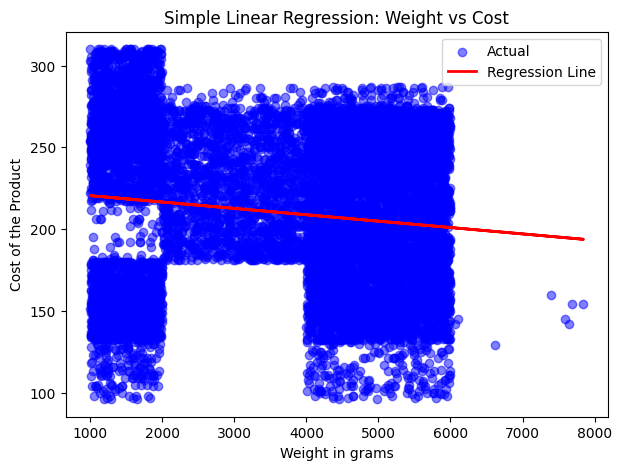

In [21]:
# Visualization of Regression Line
plt.figure(figsize=(7,5))
plt.scatter(X_lin, y_lin, color="blue", alpha=0.5, label="Actual")
plt.plot(X_lin, y_pred_lin, color="red", linewidth=2, label="Regression Line")
plt.xlabel("Weight in grams")
plt.ylabel("Cost of the Product")
plt.title("Simple Linear Regression: Weight vs Cost")
plt.legend()
plt.show()

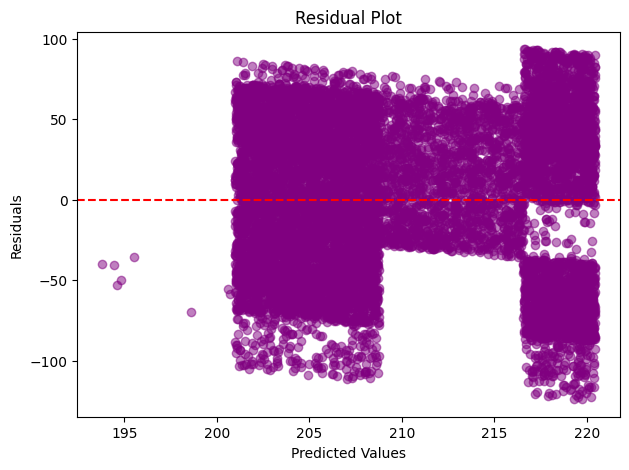

In [22]:
# Residual plot
residuals = y_lin - y_pred_lin

plt.figure(figsize=(7,5))
plt.scatter(y_pred_lin, residuals, alpha=0.5, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


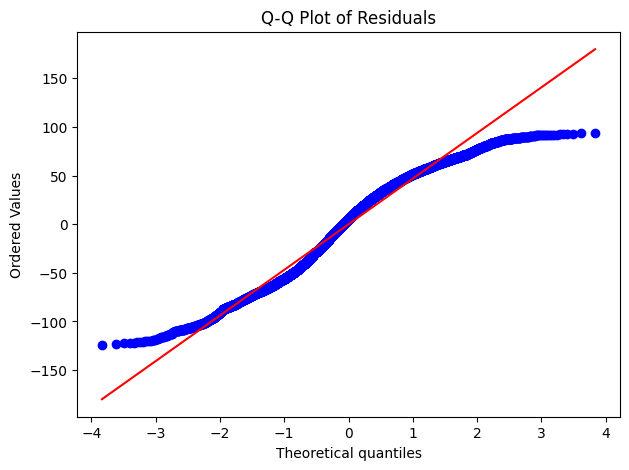

In [23]:
# Q–Q Plot (Quantile–Quantile Plot)
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

## Logistic Regression

In [15]:
# Standardize the dataset before Logistic Regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.fillna(0))
X_test_scaled = scaler.transform(X_test.fillna(0))

log_reg = LogisticRegression(max_iter=1000, solver="lbfgs")
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)

# Display outputs
print("First 10 Predictions:", y_pred[:10])
print("Accuracy on Test Data:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

First 10 Predictions: [1 1 1 1 1 1 1 0 1 0]
Accuracy on Test Data: 0.6333333333333333
Confusion Matrix:
 [[371 295]
 [310 674]]
Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.56      0.55       666
           1       0.70      0.68      0.69       984

    accuracy                           0.63      1650
   macro avg       0.62      0.62      0.62      1650
weighted avg       0.63      0.63      0.63      1650



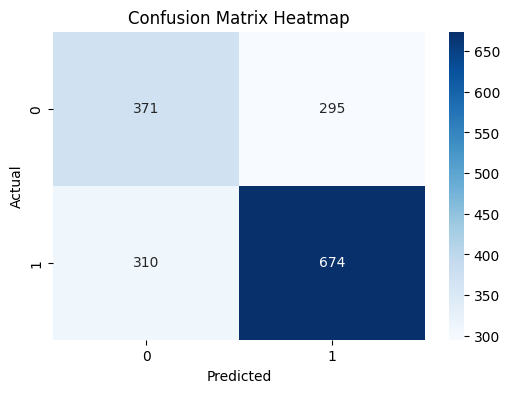

In [16]:
# Confusion Matrix Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()

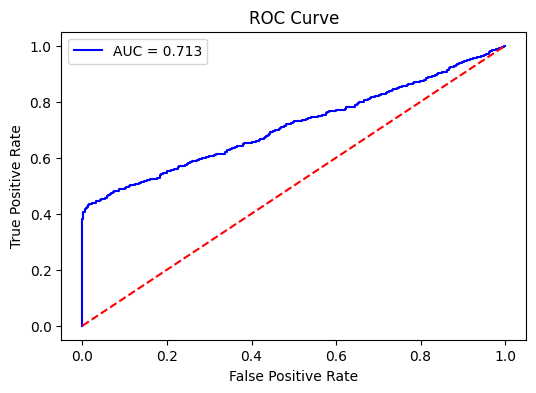

In [17]:
# ROC Curve & AUC Score
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = log_reg.predict_proba(X_test_scaled)[:,1]  # probabilities for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color="blue", label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], color="red", linestyle="--")  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 4. Hyperparameter Tuning

## GridSearchCV (Exhaustive Search)

In [24]:
# GridSearchCV for Logistic Regression
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Standardize
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.fillna(0))
X_test_scaled = scaler.transform(X_test.fillna(0))

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

model = LogisticRegression(max_iter=1000)

grid_search = GridSearchCV(model, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)
print("Test Accuracy:", grid_search.best_estimator_.score(X_test_scaled, y_test))

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.6438492696387433
Test Accuracy: 0.6345454545454545


## RandomizedSearchCV (Faster, Random Sampling)

In [25]:
# RandomizedSearchCV for Logistic Regression
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_dist = {
    "C": stats.loguniform(0.001, 100),  # random continuous values
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

random_search = RandomizedSearchCV(
    model, param_distributions=param_dist, n_iter=20, cv=5,
    scoring="accuracy", n_jobs=-1, random_state=42
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters (RandomizedSearchCV):", random_search.best_params_)
print("Best Cross-Validation Score:", random_search.best_score_)
print("Test Accuracy:", random_search.best_estimator_.score(X_test_scaled, y_test))

Best Parameters (RandomizedSearchCV): {'C': np.float64(0.0019517224641449498), 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.6493042370235352
Test Accuracy: 0.6381818181818182


## Optuna (State-of-the-art Tuning)

In [27]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 9.1 MB/s eta 0:00:00


In [32]:
# Optuna Hyperparameter Tuning for Logistic Regression
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.fillna(0))
X_test_scaled = scaler.transform(X_test.fillna(0))

def objective(trial):
    # Using suggest_float with log=True as suggest_loguniform is deprecated
    C = trial.suggest_float("C", 0.001, 100, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])

    # Suggest from the full list of solvers
    solver = trial.suggest_categorical("solver", ["liblinear", "saga", "lbfgs", "newton-cg", "sag"])

    # Check for compatibility and prune if necessary
    # Based on scikit-learn documentation for LogisticRegression
    if penalty == "l1" and solver not in ["liblinear", "saga"]:
        raise optuna.exceptions.TrialPruned(f"Solver {solver} is not compatible with penalty {penalty}")
    if penalty == "l2" and solver not in ["lbfgs", "liblinear", "newton-cg", "sag", "saga"]:
         raise optuna.exceptions.TrialPruned(f"Solver {solver} is not compatible with penalty {penalty}")
    # lbfgs, newton-cg, sag, and saga only support l2 or none
    if penalty == "l1" and solver in ["lbfgs", "newton-cg", "sag"]:
         raise optuna.exceptions.TrialPruned(f"Solver {solver} is not compatible with penalty {penalty}")
    # liblinear only supports l1 and l2
    if solver == "liblinear" and penalty not in ["l1", "l2"]:
         raise optuna.exceptions.TrialPruned(f"Solver {solver} is not compatible with penalty {penalty}")


    model = LogisticRegression(C=C, penalty=penalty, solver=solver, max_iter=1000)

    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("Best Parameters (Optuna):", study.best_params)
print("Best CV Score (Optuna):", study.best_value)

best_model = LogisticRegression(**study.best_params, max_iter=1000)
best_model.fit(X_train_scaled, y_train)
print("Test Accuracy (Optuna):", best_model.score(X_test_scaled, y_test))

[I 2025-09-20 18:03:03,556] A new study created in memory with name: no-name-67ee9976-f2a3-471c-9194-b13801c7ecbc
[I 2025-09-20 18:03:03,559] Trial 0 pruned. Solver newton-cg is not compatible with penalty l1
[I 2025-09-20 18:03:03,561] Trial 1 pruned. Solver newton-cg is not compatible with penalty l1
[I 2025-09-20 18:03:03,562] Trial 2 pruned. Solver lbfgs is not compatible with penalty l1
[I 2025-09-20 18:03:03,655] Trial 3 finished with value: 0.6419006269883464 and parameters: {'C': 0.04134907600822982, 'penalty': 'l2', 'solver': 'liblinear'}. Best is trial 3 with value: 0.6419006269883464.
[I 2025-09-20 18:03:03,656] Trial 4 pruned. Solver sag is not compatible with penalty l1
[I 2025-09-20 18:03:03,898] Trial 5 finished with value: 0.6373539066521523 and parameters: {'C': 2.3930877255410827, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 3 with value: 0.6419006269883464.
[I 2025-09-20 18:03:03,900] Trial 6 pruned. Solver sag is not compatible with penalty l1
[I 2025-09-20 18:

Best Parameters (Optuna): {'C': 0.0010031019546967877, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score (Optuna): 0.6513819059433094
Test Accuracy (Optuna): 0.6363636363636364


## Random Forest

In [33]:
# GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring="accuracy", n_jobs=-1)
grid_rf.fit(X_train_scaled, y_train)

print("Best Parameters (RF GridSearch):", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)
print("Test Accuracy:", grid_rf.best_estimator_.score(X_test_scaled, y_test))

Best Parameters (RF GridSearch): {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score: 0.6825561316803205
Test Accuracy: 0.6624242424242425


In [34]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_dist_rf = {
    "n_estimators": stats.randint(50, 300),
    "max_depth": [5, 10, 20, None],
    "min_samples_split": stats.randint(2, 11),
    "min_samples_leaf": stats.randint(1, 5),
    "max_features": ["sqrt", "log2"]
}

rand_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf,
                             n_iter=20, cv=3, scoring="accuracy",
                             n_jobs=-1, random_state=42)
rand_rf.fit(X_train_scaled, y_train)

print("Best Parameters (RF Randomized):", rand_rf.best_params_)
print("Best CV Score:", rand_rf.best_score_)
print("Test Accuracy:", rand_rf.best_estimator_.score(X_test_scaled, y_test))

Best Parameters (RF Randomized): {'max_depth': 5, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 4, 'n_estimators': 255}
Best CV Score: 0.6795692535400703
Test Accuracy: 0.6636363636363637


In [35]:
# Optuna
import optuna
from sklearn.model_selection import cross_val_score

def rf_objective(trial):
    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_categorical("max_depth", [5, 10, 20, None]),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 4),
        max_features=trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        random_state=42
    )
    scores = cross_val_score(rf, X_train_scaled, y_train, cv=3, scoring="accuracy")
    return scores.mean()

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(rf_objective, n_trials=30)

print("Best Parameters (RF Optuna):", study_rf.best_params)
print("Best CV Score:", study_rf.best_value)

best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)
best_rf.fit(X_train_scaled, y_train)
print("Test Accuracy (RF Optuna):", best_rf.score(X_test_scaled, y_test))

[I 2025-09-20 18:11:58,497] A new study created in memory with name: no-name-7de0098f-5da4-43b2-88b4-b94c048ba2e4
[I 2025-09-20 18:12:00,214] Trial 0 finished with value: 0.6778801995833562 and parameters: {'n_estimators': 167, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6778801995833562.
[I 2025-09-20 18:12:01,553] Trial 1 finished with value: 0.6671001518868246 and parameters: {'n_estimators': 58, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.6778801995833562.
[I 2025-09-20 18:12:06,577] Trial 2 finished with value: 0.6598262435778045 and parameters: {'n_estimators': 220, 'max_depth': 20, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6778801995833562.
[I 2025-09-20 18:12:09,175] Trial 3 finished with value: 0.658786405344813 and parameters: {'n_estimators': 127, 'max_depth': 20, 'min_

Best Parameters (RF Optuna): {'n_estimators': 195, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Best CV Score: 0.6804781251900862
Test Accuracy (RF Optuna): 0.666060606060606


## XGBoost

In [39]:
# GridSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Remove use_label_encoder as it's deprecated
xgb = XGBClassifier(eval_metric="logloss", random_state=42)

param_grid_xgb = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring="accuracy", n_jobs=-1)
grid_xgb.fit(X_train_scaled, y_train)

print("Best Parameters (XGB GridSearch):", grid_xgb.best_params_)
print("Best CV Score:", grid_xgb.best_score_)
print("Test Accuracy:", grid_xgb.best_estimator_.score(X_test_scaled, y_test))

Best Parameters (XGB GridSearch): {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
Best CV Score: 0.6854139662399726
Test Accuracy: 0.6836363636363636


In [40]:
# RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
from xgboost import XGBClassifier # Import XGBClassifier here as well

# Remove use_label_encoder as it's deprecated
xgb = XGBClassifier(eval_metric="logloss", random_state=42)

param_dist_xgb = {
    "n_estimators": stats.randint(50, 300),
    "max_depth": stats.randint(3, 10),
    "learning_rate": stats.uniform(0.01, 0.3),
    "subsample": stats.uniform(0.7, 0.3),
    "colsample_bytree": stats.uniform(0.7, 0.3)
}

rand_xgb = RandomizedSearchCV(xgb, param_distributions=param_dist_xgb,
                              n_iter=20, cv=3, scoring="accuracy",
                              n_jobs=-1, random_state=42)
rand_xgb.fit(X_train_scaled, y_train)

print("Best Parameters (XGB Randomized):", rand_xgb.best_params_)
print("Best CV Score:", rand_xgb.best_score_)
print("Test Accuracy:", rand_xgb.best_estimator_.score(X_test_scaled, y_test))

Best Parameters (XGB Randomized): {'colsample_bytree': np.float64(0.722213395520227), 'learning_rate': np.float64(0.11753971856328177), 'max_depth': 3, 'n_estimators': 77, 'subsample': np.float64(0.958931027762678)}
Best CV Score: 0.680088615997983
Test Accuracy: 0.683030303030303


In [41]:
# Optuna
import optuna
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

def xgb_objective(trial):
    # Using suggest_float with log=True as suggest_loguniform is deprecated
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    subsample = trial.suggest_float("subsample", 0.7, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.7, 1.0)

    # XGBoost parameters are generally compatible with each other,
    # so direct pruning based on simple combinations might not be necessary
    # unless there are specific known incompatibilities or constraints.
    # For standard XGBoost, the suggested parameters are generally valid together.

    xgb = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 50, 300),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        eval_metric="logloss",
        random_state=42
    )
    scores = cross_val_score(xgb, X_train_scaled, y_train, cv=3, scoring="accuracy")
    return scores.mean()

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgb_objective, n_trials=30)

print("Best Parameters (XGB Optuna):", study_xgb.best_params)
print("Best CV Score:", study_xgb.best_value)

best_xgb = XGBClassifier(**study_xgb.best_params, eval_metric="logloss", random_state=42)
best_xgb.fit(X_train_scaled, y_train)
print("Test Accuracy (XGB Optuna):", best_xgb.score(X_test_scaled, y_test))

[I 2025-09-20 18:17:09,634] A new study created in memory with name: no-name-d6b5126b-4f53-4a95-a65f-2c0a271ac4c3
[I 2025-09-20 18:17:09,783] Trial 0 finished with value: 0.5976100825241288 and parameters: {'learning_rate': 0.010683238577628474, 'subsample': 0.8753311574976427, 'colsample_bytree': 0.8255509925367371, 'n_estimators': 52, 'max_depth': 4}. Best is trial 0 with value: 0.5976100825241288.
[I 2025-09-20 18:17:10,404] Trial 1 finished with value: 0.6532019558351129 and parameters: {'learning_rate': 0.14683256961885366, 'subsample': 0.8397082371174773, 'colsample_bytree': 0.7783304357074838, 'n_estimators': 222, 'max_depth': 5}. Best is trial 1 with value: 0.6532019558351129.
[I 2025-09-20 18:17:10,728] Trial 2 finished with value: 0.6784006247531092 and parameters: {'learning_rate': 0.02041313695192102, 'subsample': 0.7073701328322213, 'colsample_bytree': 0.8323909065975612, 'n_estimators': 120, 'max_depth': 5}. Best is trial 2 with value: 0.6784006247531092.
[I 2025-09-20 18

Best Parameters (XGB Optuna): {'learning_rate': 0.03995724310751496, 'subsample': 0.8594539491534092, 'colsample_bytree': 0.7503155577999983, 'n_estimators': 133, 'max_depth': 3}
Best CV Score: 0.6855437689004565
Test Accuracy (XGB Optuna): 0.6812121212121212
